In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import joblib
import pickle
import matplotlib.pyplot as plt
from xgboost import plot_importance

In [3]:
df = pd.read_csv('data/drom_archive_cleaned_2018-2025new.csv')
df_cheap = df[df['Цена'] <= 700_000]
df_mid = df[(df['Цена'] >= 500_000) & (df['Цена'] < 2_000_000)]
df_exp = df[df['Цена'] >= 2_000_000]
df_mid['log_price'] = np.log(df_mid['Цена'])

Text(0, 0.5, 'Количество автомобилей')

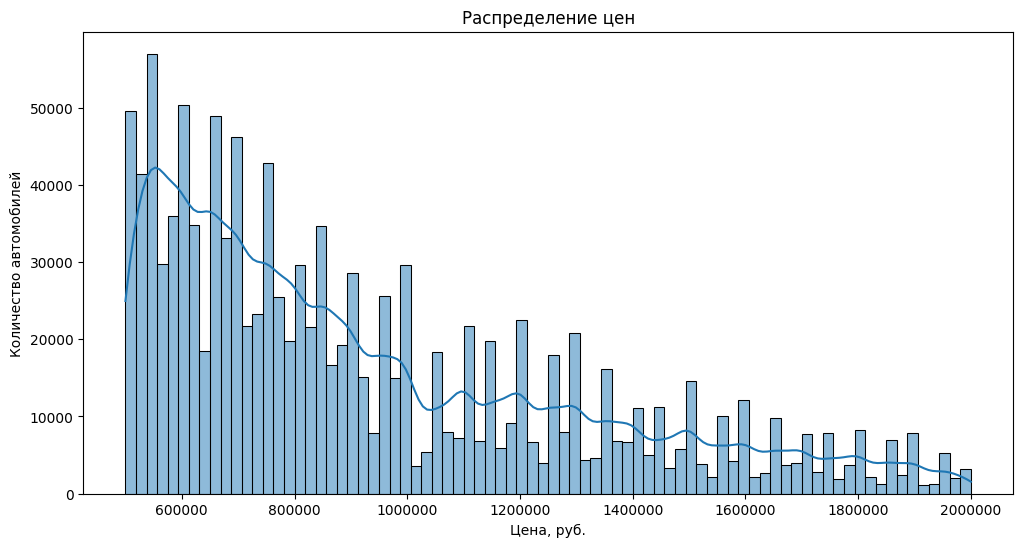

In [4]:
plt.figure(figsize=(12, 6))
sns.histplot(df_mid["Цена"], bins=80, kde=True)
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Распределение цен')
plt.xlabel("Цена, руб.")
plt.ylabel("Количество автомобилей")

In [5]:
categorical = ['Тип двигателя', 'Коробка передач', 'Привод', 'Поколение', 'Рестайлинг',
               'Тип кузова', 'Метка', 'Город']
numerical = ['Год', 'Объем двигателя', 'Мощность', 'Пробег', 'Возраст авто']

In [6]:
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical), ('num', 'passthrough', numerical)], remainder='drop')

In [7]:
#y = df_mid['Цена']
#X = df_mid.drop('Цена', axis=1)
y = df_mid['log_price'] # Целевая переменная теперь логарифм цены
X = df_mid.drop(['Цена', 'log_price'], axis=1)

X_train = X[X['Год объявления'] <= 2023]
X_test = X[X['Год объявления'] >= 2024]

y_train = y[X['Год объявления'] <= 2023]
y_test = y[X['Год объявления'] >= 2024]
'''
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=1000,
        n_jobs=-1,
        random_state=42,
        eval_metric='rmse'
    ))
])
'''
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=2000,
        n_jobs=-1,
        random_state=42,
        eval_metric='rmse'
    ))
])
model.fit(X_train, y_train, regressor__verbose=True)
y_pred_log = model.predict(X_test)

y_pred = np.exp(y_pred_log) # Обратное преобразование прогнозов
y_test_real = np.exp(y_test)

In [8]:
xg_mse = mean_squared_error(y_test_real, y_pred)
xg_rmse = np.sqrt(xg_mse)
xg_mae = mean_absolute_error(y_test_real, y_pred)
xg_r2 = r2_score(y_test_real, y_pred)

In [9]:
pd.options.display.float_format = '{:_.2f}'.format
pd.DataFrame({
    'Метод оценки': ['Среднеквадратическая ошибка (MSE)', 'Среднеквадратическая ошибка (RMSE)', 'Средняя абсолютная ошибка (MAE)', 'Коэффицент детерминации (R^2)'],
    'Результаты': [xg_mse, xg_rmse, xg_mae, xg_r2]
})

,Метод оценки,Результаты
0,Среднеквадратическая ошибка (MSE),43_513_012_420.57
1,Среднеквадратическая ошибка (RMSE),208_597.73
2,Средняя абсолютная ошибка (MAE),155_844.60
3,Коэффицент детерминации (R^2),0.72


In [10]:
np.mean(df_mid['Цена'])

np.float64(932699.9560700828)

In [11]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test_real, y_pred)
print(f"MAPE: {mape:.2%}")

MAPE: 14.76%


In [12]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

importances = model.named_steps['regressor'].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("TOP 20 признаков:")
print(importance_df.head(20))


TOP 20 признаков:
                             feature  importance
3192                        num__Год        0.05
63                   cat__Метка_lada        0.04
66                  cat__Метка_lexus        0.04
10              cat__Привод_передний        0.03
6      cat__Коробка передач_редуктор        0.03
3194                   num__Мощность        0.03
3193            num__Объем двигателя        0.02
79                 cat__Метка_toyota        0.02
34    cat__Тип кузова_джип/suv 5 дв.        0.02
57                  cat__Метка_honda        0.02
54                  cat__Метка_geely        0.01
4          cat__Коробка передач_МКПП        0.01
21               cat__Поколение_11.0        0.01
3196               num__Возраст авто        0.01
50                  cat__Метка_chery        0.01
52                cat__Метка_citroen        0.01
51              cat__Метка_chevrolet        0.01
40             cat__Тип кузова_седан        0.01
72                cat__Метка_peugeot        0.01
53

In [13]:
importance_df["feature_group"] = importance_df["feature"].apply(
    lambda x: x.split("__")[1].split("_")[0]
)

grouped_importance = (
    importance_df
    .groupby("feature_group")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print("\nВажность исходных признаков:")
print(grouped_importance)


Важность исходных признаков:
feature_group
Город             0.41
Метка             0.25
Тип кузова        0.07
Поколение         0.05
Коробка передач   0.05
Год               0.05
Привод            0.03
Мощность          0.03
Объем двигателя   0.02
Рестайлинг        0.01
Возраст авто      0.01
Тип двигателя     0.00
Пробег            0.00
Name: importance, dtype: float32


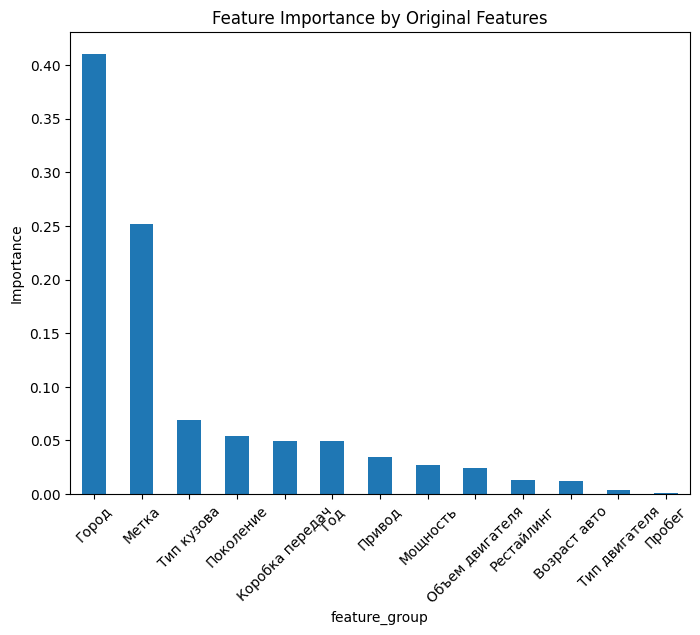

In [14]:
plt.figure(figsize=(8,6))
grouped_importance.plot(kind="bar")
plt.title("Feature Importance by Original Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()